In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
if os.path.exists(".env"):
    load_dotenv()
    print("Environment variables loaded from .env file.")


# Access the API key
api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    print("API Key loaded successfully!")
else:
    print("API Key not found. Please check your .env file.")

API Key loaded successfully!


In [2]:
pip install langgraph

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install langchain

Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import TypedDict, List, Dict, Optional

class AgentState(TypedDict):
    message: str
    profile: Dict[str, str]
    need: Optional[str]
    documents: List[str]
    sources: List[str]
    missing_info: List[str]
    suggested_actions: List[str]
    uploaded_files: List[str]
    downloadable_links: List[str]
    conversation_history: List[Dict[str, str]]


In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

chat = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def llm_response_node(state: AgentState) -> AgentState:
    context = ""

    # S'il y a des fichiers envoyés, on les injecte
    if state.get("uploaded_files"):
        context = "Documents fournis : " + ", ".join(state["uploaded_files"])

    messages = [
        SystemMessage(content="Tu es un assistant administratif français. Aide l'utilisateur avec précision."),
        HumanMessage(content=f"Message utilisateur : {state['message']}\nContexte : {context}")
    ]

    # Appel LLM
    response = chat.invoke(messages).content

    # On l'ajoute comme suggestion
    state["suggested_actions"].append(response)

    # Sauvegarde dans l’historique
    state.setdefault("conversation_history", [])
    state["conversation_history"].append({
        "user": state["message"],
        "assistant": response
    })

    return state


In [5]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from ddgs import DDGS
from PyPDF2 import PdfReader


@tool
def web_search(query: str) -> str:
    """Searches the web for official info & admin procedures."""
    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=5))
    if not results:
        return "Aucun résultat trouvé."
    return "; ".join([f"{r['title']} — {r['body']}" for r in results])


@tool
def document_parser(file_path: str) -> str:
    """Extract text from an uploaded PDF."""
    reader = PdfReader(file_path)
    text = "\n".join(page.extract_text() for page in reader.pages)
    return text.strip()

@tool
def fetch_official_form(need: str) -> str:
    """Return official form or application link."""
    urls = {
        "APL": "https://www.caf.fr/allocataire/formulaire-apl.pdf",
        "IMPOTS": "https://www.impots.gouv.fr/formulaire.pdf",
        "AMELI": "https://www.ameli.fr/formulaire.pdf",
        "RSA": "https://www.caf.fr/rsa-form.pdf",
        "VISA": "https://france-visas.gouv.fr/",
        "CROUS": "https://www.messervices.etudiant.gouv.fr/"
    }
    return urls.get(need.upper(), "Pas de formulaire officiel trouvé.")

@tool
def checklist_generator(state: dict) -> str:
    """Generate a personalized document checklist."""
    checklist = f"Checklist pour {state.get('need', 'démarche')}:\n"
    for doc in state.get('documents', []):
        checklist += f"- {doc}\n"
    return checklist.strip()

@tool
def generate_links(documents: list) -> list:
    """Generate downloadable links for doc templates."""
    return [
        f"https://example.com/forms/{doc.replace(' ', '_')}.pdf"
        for doc in documents
    ]
@tool
def translate_text(text: str, target_language: str = "fr") -> str:
    """Translate user text into French or another language."""
    return f"[Traduction simulée en {target_language}] {text}"

@tool
def explain_procedure(need: str) -> str:
    """Explain an administrative procedure in plain French."""
    explanations = {
        "APL": "Pour obtenir l'APL, il faut un bail à ton nom et un compte CAF...",
        "VISA": "Pour obtenir un visa étudiant, il faut une attestation d'école...",
        "AMELI": "Tu dois créer ton compte Ameli et envoyer ton RIB..."
    }
    return explanations.get(need.upper(), "Procédure inconnue.")

@tool
def analyze_situation(message: str) -> str:
    """Extracts key admin needs from user message."""
    msg = message.lower()
    if "logement" in msg or "loyer" in msg:
        return "APL"
    if "visa" in msg or "etranger" in msg:
        return "VISA"
    if "mutuelle" in msg or "ameli" in msg:
        return "AMELI"
    if "bourse" in msg or "crous" in msg:
        return "CROUS"
    return "UNKNOWN"

tools = [
    web_search,
    document_parser,
    fetch_official_form,
    checklist_generator,
    generate_links,
    translate_text,
    explain_procedure,
    analyze_situation,
]

tool_node = ToolNode(tools)

In [6]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# ================== NODES ==================

def llm_node(state: AgentState) -> AgentState:
    uploaded_docs = state.get("uploaded_files", [])
    prompt = f"""
    Analyse le message et suggère le besoin probable :
    Message utilisateur : {state['message']}
    Documents fournis : {', '.join(uploaded_docs) if uploaded_docs else 'aucun'}
    """
    llm_response = llm_invoke(prompt)  # appel réel au LLM
    state["llm_suggestion"] = llm_response
    return state


def detect_need_node(state: AgentState) -> AgentState:
    msg = state.get("llm_suggestion", state["message"]).lower()
    if "logement" in msg or "apl" in msg:
        state["need"] = "APL"
    elif "impôt" in msg or "déclaration" in msg:
        state["need"] = "IMPOTS"
    elif "sécurité sociale" in msg or "ameli" in msg:
        state["need"] = "AMELI"
    elif "rsa" in msg:
        state["need"] = "RSA"
    elif "visa" in msg or "étranger" in msg:
        state["need"] = "FOREIGN"
    else:
        state["need"] = "UNKNOWN"
    return state

def verify_profile_node(state: AgentState) -> AgentState:
    missing = []
    for field in ["age", "nationality", "residency_status"]:
        if field not in state["profile"]:
            missing.append(field)
    state["missing_info"] = missing
    return state

def decide_next_node(state: AgentState) -> str:
    if state["missing_info"]:
        return "ask_missing_info"
    elif state["need"] == "UNKNOWN":
        return "llm"  # boucle vers LLM si besoin inconnu
    else:
        return "tools"  # tools avant génération docs

def ask_missing_info_node(state: AgentState) -> AgentState:
    state["suggested_actions"].append(
        f"Demander infos manquantes : {', '.join(state['missing_info'])}"
    )
    return state

def suggest_actions_node(state: AgentState) -> AgentState:
    if state["need"] != "UNKNOWN":
        state["suggested_actions"].append(f"Fournir documents pour {state['need']}")
        state["suggested_actions"].append("Indiquer sources fiables")
        state["downloadable_links"] = [
            f"https://example.com/{doc.replace(' ', '_')}.pdf"
            for doc in state["documents"]
        ]
        if state.get("uploaded_files"):
            state["suggested_actions"].append(
                f"Documents reçus : {', '.join(state['uploaded_files'])}"
            )
    return state

def download_links_node(state: AgentState) -> AgentState:
    state["suggested_actions"].append(
        "L'utilisateur peut télécharger les documents ici"
    )
    return state

def should_download_links(state: AgentState) -> str:
    if state.get("downloadable_links"):
        return "download_links"
    return END

def document_node(state: AgentState) -> AgentState:
    docs, sources = [], []
    need = state.get("need", "UNKNOWN")
    if need == "APL":
        docs = ["Carte d’identité", "Justificatif de domicile", "RIB"]
        sources = ["CAF.fr"]
    elif need == "IMPOTS":
        docs = ["Numéro fiscal", "Relevé de salaire"]
        sources = ["Impots.gouv.fr"]
    elif need == "AMELI":
        docs = ["Carte d’identité", "Numéro de sécurité sociale"]
        sources = ["Ameli.fr"]
    elif need == "RSA":
        docs = ["Carte d’identité", "Relevé bancaire"]
        sources = ["CAF.fr"]
    elif need == "FOREIGN":
        docs = ["Passeport", "Visa", "Justificatif de domicile"]
        sources = ["Service-Public.fr"]
    state["documents"] = docs
    state["sources"] = sources
    return state

# ================== GRAPH SETUP ==================

graph = StateGraph(AgentState)

# Supposons que tu as déjà créé ton ToolNode comme ceci :
# tool_node = ToolNode(tools)

# Nodes
graph.add_node("llm", llm_node)
graph.add_node("detect_need", detect_need_node)
graph.add_node("verify_profile", verify_profile_node)
graph.add_node("decide_next", decide_next_node)
graph.add_node("ask_missing_info", ask_missing_info_node)
graph.add_node("tools", tool_node)  # ici ton ToolNode déjà initialisé
graph.add_node("gen_docs", document_node)
graph.add_node("suggest_actions", suggest_actions_node)
graph.add_node("download_links", download_links_node)

# Entry point
graph.set_entry_point("llm")

# Linear flow
graph.add_edge("llm", "detect_need")
graph.add_edge("detect_need", "verify_profile")
graph.add_edge("verify_profile", "decide_next")

# Conditional flow after decide_next
graph.add_conditional_edges(
    "decide_next",
    decide_next_node,
    {
        "ask_missing_info": "ask_missing_info",
        "llm": "llm",
        "tools": "tools"
    }
)

# Edge après ask_missing_info pour continuer vers tools
graph.add_edge("ask_missing_info", "tools")

# Tools flow
graph.add_edge("tools", "gen_docs")
graph.add_edge("gen_docs", "suggest_actions")

# Conditional flow for download links
graph.add_conditional_edges(
    "suggest_actions",
    should_download_links,
    {
        "download_links": "download_links",
        END: END
    }
)

# Finish point
graph.set_finish_point("download_links")

# Compile
app1 = graph.compile()



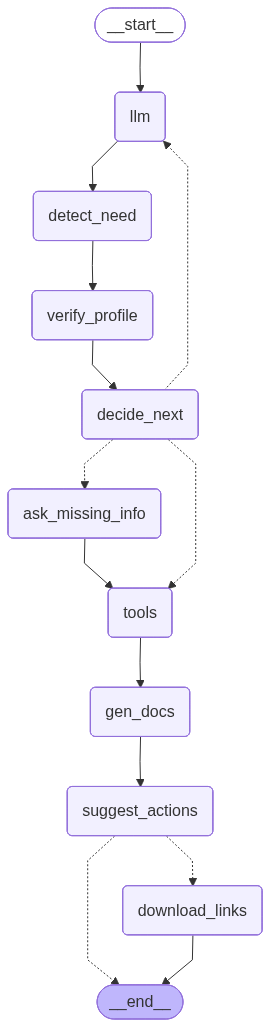

In [7]:
from IPython.display import display, Image

# Affiche le graph compilé en PNG
display(Image(app1.get_graph().draw_mermaid_png()))

In [32]:
pip show langgraph


Name: langgraph
Version: 1.0.1
Summary: Building stateful, multi-actor applications with LLMs
Home-page: 
Author: 
Author-email: 
License-Expression: MIT
Location: /opt/anaconda3/lib/python3.12/site-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain, langgraph-supervisor
Note: you may need to restart the kernel to use updated packages.


In [34]:
# Ton code pour créer le graph et les nodes (LLM, detect_need, tools, gen_docs, etc.)

# Compile le graph
app1 = graph.compile()

# Crée un état de test
state = {
    "message": "Je veux des infos sur l'APL",
    "profile": {"age": 25, "nationality": "Française"},
    "uploaded_files": [],
    "suggested_actions": [],
}

# Exécute le graph
final_state = app1.run(state)  # ✅ devrait fonctionner maintenant

# Affiche les résultats
print("Besoin détecté:", final_state.get("need"))
print("Infos manquantes:", final_state.get("missing_info"))
print("Documents générés:", final_state.get("documents"))
print("Actions suggérées:", final_state.get("suggested_actions"))
print("Liens téléchargeables:", final_state.get("downloadable_links"))


AttributeError: 'CompiledStateGraph' object has no attribute 'run'

In [28]:
test_messages = [
    "Je veux des infos sur l'APL",
    "Je veux déclarer mes impôts",
    "Je suis étranger et je veux un visa",
    "Je ne sais pas quoi demander",
]

for msg in test_messages:
    state = {
        "message": msg,
        "profile": {"age": 25, "nationality": "Française"},  # test avec profil incomplet
        "uploaded_files": [],
        "suggested_actions": [],
    }
    final_state = app1.run(state)  # ✅ .run() compatible LangGraph 1.0.1
    print("\n==============================")
    print(f"Message: {msg}")
    print("Besoin détecté:", final_state.get("need"))
    print("Infos manquantes:", final_state.get("missing_info"))
    print("Documents générés:", final_state.get("documents"))
    print("Actions suggérées:", final_state.get("suggested_actions"))
    print("Liens téléchargeables:", final_state.get("downloadable_links"))





AttributeError: 'CompiledStateGraph' object has no attribute 'run'

In [31]:
pip show langgraph
pip show langchain


SyntaxError: invalid syntax (3447111851.py, line 1)

In [22]:
print("Besoin détecté :", final_state.get("need"))
print("Infos manquantes :", final_state.get("missing_info"))
print("Documents générés :", final_state.get("documents"))
print("Actions suggérées :", final_state.get("suggested_actions"))
print("Liens téléchargeables :", final_state.get("downloadable_links"))




NameError: name 'final_state' is not defined